# Neural Retrieval

Previous retrieval models relied on fixed user and item representations (genre/tag vectors, then review embeddings) compared with cosine similarity. In this notebook, both representations are **learned jointly** from interaction data, allowing the retrieval model to optimize directly for the recommendation task. A Two-Tower neural model produces a shared embedding space, and FAISS performs fast candidate retrieval.

Stage in the project: `Classical Retrieval → Semantic Retrieval → `**`Neural Retrieval`**` → Learning to Rank`.

## Нейронный retrieval

Предыдущие retrieval-модели опирались на фиксированные представления пользователей и игр (векторы жанров/тегов, затем эмбеддинги отзывов), сравниваемые по cosine. В этом ноутбуке оба представления **обучаются совместно** из данных о взаимодействиях, что позволяет retrieval-модели оптимизироваться напрямую под задачу рекомендаций. Нейронная Two-Tower модель строит общее пространство эмбеддингов, а FAISS выполняет быстрый поиск кандидатов.

Этап проекта: `Classical Retrieval → Semantic Retrieval → `**`Neural Retrieval`**` → Learning to Rank`.

In [ ]:
import os
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore", message=".*Disabling GPU support.*")

# Project root directory
# Корневая директория проекта
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data"

# Make src importable and load models, features, retrieval, evaluation
# Делаем src импортируемым и подключаем модели, фичи, retrieval, оценку
sys.path.insert(0, str(ROOT))
from src.features.two_tower_features import build_two_tower_data
from src.retrieval import TwoTower
from src.baselines import (PopularityRecommender, ContentBasedRecommender,
                           ALSRecommender, SemanticEmbeddingRecommender,
                           TwoTowerRecommender)
from src.evaluation import evaluate

# Plot style
# Стиль графиков
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("cuda available:", torch.cuda.is_available())

cuda available: True


## Load Data

Same frozen split and game metadata, plus the semantic game embeddings from Notebook 04 — these become an input to the item tower, which nicely ties the stages together.

## Загрузка данных

Тот же зафиксированный split и метаданные игр, плюс семантические эмбеддинги игр из Ноутбука 04 — они становятся входом item-башни, что красиво связывает этапы.

In [ ]:
train = pd.read_parquet(DATA / "processed" / "train.parquet")
test = pd.read_parquet(DATA / "processed" / "test.parquet")
games = pd.read_parquet(DATA / "processed" / "games.parquet")

emb_meta = pd.read_parquet(DATA / "processed" / "game_embeddings_metadata.parquet").sort_values("embedding_idx")
game_emb = np.load(DATA / "processed" / "game_embeddings.npy")
game_ids = emb_meta["game_id"].to_numpy()

name_by_id = games.set_index("game_id")["Name"].to_dict()
print("train:", train.shape, "| test:", test.shape, "| game embeddings:", game_emb.shape)

train: (787585, 5) | test: (113552, 5) | game embeddings: (2759, 384)


## Feature Pipeline

The two towers consume engineered features (no raw user/item IDs), so the model generalizes by feature rather than memorizing identities.

- **Item features**: review embedding (384-d) + multi-hot genres + multi-hot tags + price + review score.
- **User features**: genre/tag history profile + numeric stats (avg playtime, positive ratio, avg price, number of games).

Unlike previous stages, the semantic review embedding becomes just one component of the item representation rather than the final representation itself. User features are constructed from the training history only — during evaluation, the held-out interaction is never used to build user representations.

## Конвейер признаков

Обе башни используют сконструированные признаки (без сырых ID юзера/игры), поэтому модель обобщает по признакам, а не запоминает идентификаторы.

- **Признаки айтема**: эмбеддинг отзывов (384) + multi-hot жанры + multi-hot теги + цена + review score.
- **Признаки юзера**: профиль истории по жанрам/тегам + числовые статистики (среднее время игры, доля позитивных, средняя цена, число игр).

В отличие от предыдущих этапов, семантический эмбеддинг отзывов становится лишь одним из компонентов представления айтема, а не самим финальным представлением. Признаки юзера строятся только из train-истории — на оценке отложенное взаимодействие никогда не используется для построения представления юзера.

In [ ]:
# Build feature tensors (for inspection; the recommender rebuilds them internally)
# Строим тензоры признаков (для осмотра; рекомендер пересоберёт их внутри)
data = build_two_tower_data(train, games, game_emb, game_ids)
print("items:", len(data["item_ids"]), "| users:", len(data["user_ids"]),
      "| training pairs:", f"{len(data['pairs']):,}")
print("item review-emb dim:", data["item_emb"].shape[1],
      "| item struct dim:", data["item_struct"].shape[1])
print("user history dim:", data["user_hist"].shape[1],
      "| user numeric dim:", data["user_num"].shape[1])

items: 2759 | users: 113552 | training pairs: 771,807
item review-emb dim: 384 | item struct dim: 461
user history dim: 459 | user numeric dim: 4


## Two-Tower Architecture

The two towers are trained independently but projected into the **same** embedding space, where matching user-item pairs obtain higher cosine similarity. This separation is what makes retrieval efficient: item embeddings are precomputed once and indexed, and only the user embedding is computed at request time.

Each tower has two branches fused into a single 64-d embedding, kept compact to suit the small catalog:

- **Item tower**: review embedding → Linear(128); structured features → Linear(32); concat → Linear(64).
- **User tower**: history profile → Linear(32); numeric stats → Linear(16); concat → Linear(64).

Outputs are L2-normalized, so the inner product equals cosine similarity.

## Архитектура Two-Tower

Две башни обучаются независимо, но проецируются в **одно** пространство эмбеддингов, где подходящие пары пользователь–игра получают более высокий cosine. Именно это разделение делает retrieval эффективным: эмбеддинги игр считаются один раз и индексируются, а на запрос вычисляется только эмбеддинг пользователя.

У каждой башни две ветки, сливающиеся в один 64-мерный эмбеддинг; башни компактные под маленький каталог:

- **Item tower**: эмбеддинг отзывов → Linear(128); структурные признаки → Linear(32); concat → Linear(64).
- **User tower**: профиль истории → Linear(32); числовые признаки → Linear(16); concat → Linear(64).

Выходы L2-нормированы, поэтому inner product равен cosine.

In [ ]:
# Show the architecture (not trained here; training happens below)
# Показываем архитектуру (здесь не обучаем; обучение ниже)
demo = TwoTower(emb_dim=data["item_emb"].shape[1], struct_dim=data["item_struct"].shape[1],
                hist_dim=data["user_hist"].shape[1], num_dim=data["user_num"].shape[1])
print(demo)

TwoTower(
  (item_tower): ItemTower(
    (emb_branch): Sequential(
      (0): Linear(in_features=384, out_features=128, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (struct_branch): Sequential(
      (0): Linear(in_features=461, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (head): Linear(in_features=160, out_features=64, bias=True)
  )
  (user_tower): UserTower(
    (hist_branch): Sequential(
      (0): Linear(in_features=459, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (num_branch): Sequential(
      (0): Linear(in_features=4, out_features=16, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.2, inplace=False)
    )
    (head): Linear(in_features=48, out_features=64, bias=True)
  )
)


## Training

Each training batch consists of observed user-item interactions. Other items within the same batch act as implicit negative examples, allowing the model to learn discriminative user and item representations without explicit negative sampling. A softmax cross-entropy over the batch pulls each user towards their game and pushes them away from the others.

```
batch of positives:   (u1,g1) (u2,g2) ... (uB,gB)

            g1   g2   ...  gB
      u1 [  +    -    ...   -  ]
      u2 [  -    +    ...   -  ]   diagonal = positives
      ...
      uB [  -    -    ...   +  ]
```

Test Recall@10 is logged every 2 epochs for monitoring only — the model trains for a fixed number of epochs with no early stopping or selection on it.

## Обучение

Каждый обучающий батч состоит из наблюдаемых взаимодействий пользователь–игра. Остальные игры в том же батче выступают неявными негативами, что позволяет модели учить различающие представления пользователей и игр без явного сэмплирования негативов. Softmax cross-entropy по батчу притягивает юзера к его игре и отталкивает от остальных.

```
батч позитивов:   (u1,g1) (u2,g2) ... (uB,gB)

            g1   g2   ...  gB
      u1 [  +    -    ...   -  ]
      u2 [  -    +    ...   -  ]   диагональ = позитивы
      ...
      uB [  -    -    ...   +  ]
```

Test Recall@10 логируется каждые 2 эпохи только для мониторинга — модель учится фиксированное число эпох, без early stopping и отбора по нему.

In [ ]:
# Train the Two-Tower recommender (test used only to monitor Recall@10)
# Обучаем Two-Tower рекомендер (test — только для мониторинга Recall@10)
two_tower = TwoTowerRecommender(games, game_emb, game_ids, epochs=10, seed=42)
two_tower.fit(train, eval_test=test)

epoch  1  loss 6.0461


epoch  2  loss 5.6009  test recall@10 0.0612


epoch  3  loss 5.4975


epoch  4  loss 5.4389  test recall@10 0.0648


epoch  5  loss 5.3932


epoch  6  loss 5.3587  test recall@10 0.0628


epoch  7  loss 5.3314


epoch  8  loss 5.3096  test recall@10 0.0700


epoch  9  loss 5.2912


epoch 10  loss 5.2759  test recall@10 0.0713


## Training Curves

Loss should decrease while monitored Recall@10 increases — evidence that lowering the loss actually improves recommendation quality, not just the objective.

## Кривые обучения

Loss должен падать, а отслеживаемый Recall@10 — расти: это показывает, что снижение лосса реально улучшает качество рекомендаций, а не только саму целевую функцию.

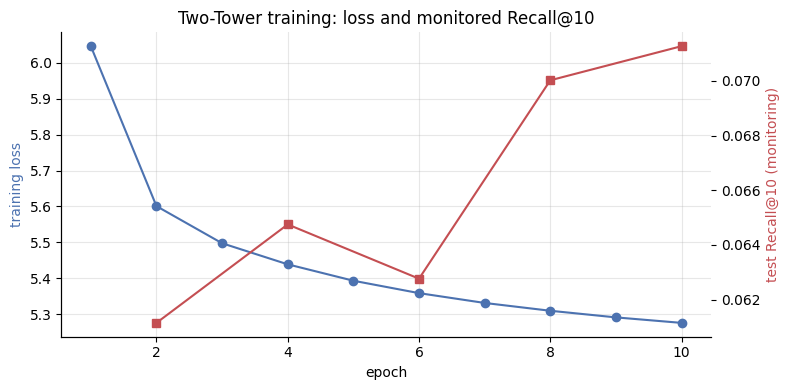

In [ ]:
h = pd.DataFrame(two_tower.history_)
rec = h.dropna(subset=["recall@10"])

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(h["epoch"], h["loss"], color="#4C72B0", marker="o", label="loss")
ax1.set_xlabel("epoch")
ax1.set_ylabel("training loss", color="#4C72B0")

ax2 = ax1.twinx()
ax2.grid(False)
ax2.plot(rec["epoch"], rec["recall@10"], color="#C44E52", marker="s", label="test Recall@10")
ax2.set_ylabel("test Recall@10 (monitoring)", color="#C44E52")
ax1.set_title("Two-Tower training: loss and monitored Recall@10")
plt.tight_layout()
plt.show()

Both the decreasing loss and the increasing Recall@10 indicate that the model successfully learns a shared embedding space despite the limited interaction data.

Падающий loss и растущий Recall@10 вместе показывают, что модель успешно учит общее пространство эмбеддингов, несмотря на ограниченный объём данных о взаимодействиях.

## Build FAISS

After training, all learned item embeddings are stored in a FAISS `IndexFlatIP`. Because the embeddings are L2-normalized, inner product equals cosine similarity, so retrieval returns the games closest to a user's learned embedding.

## Сборка FAISS

После обучения все обученные эмбеддинги игр кладутся в FAISS `IndexFlatIP`. Так как эмбеддинги L2-нормированы, inner product равен cosine, и retrieval возвращает игры, ближайшие к обученному эмбеддингу юзера.

In [ ]:
print("FAISS index size:", two_tower.index_.ntotal, "items |",
      "embedding dim:", two_tower.item_emb_out_.shape[1])

# Example: top-10 retrieved games for one test user
# Пример: топ-10 найденных игр для одного test-юзера
u = int(test["user_id"].iloc[0])
print(f"\nrecommendations for user {u}:")
for g in two_tower.recommend([u], k=10)[u]:
    print("  ", name_by_id.get(g, g))

FAISS index size: 2759 items | embedding dim: 64

recommendations for user 76561197960268765:
   WARRIORS OROCHI 4
   Tokyo Xanadu eX+
   Capcom Beat 'Em Up Bundle
   THE KING OF FIGHTERS 2002 UNLIMITED MATCH
   Street Fighter 30th Anniversary Collection
   DRAGON QUEST HEROES™ Slime Edition
   Ys SEVEN
   THE KING OF FIGHTERS XIV STEAM EDITION
   THE KING OF FIGHTERS '98 ULTIMATE MATCH FINAL EDITION
   SOULCALIBUR VI


## Neural Retrieval Benchmark

We evaluate every retrieval model on the same protocol and add the Two-Tower row.

## Бенчмарк нейронного retrieval

Оцениваем все retrieval-модели на одном протоколе и добавляем строку Two-Tower.

/home/mchunikhin/miniconda3/envs/rapids/lib/python3.11/site-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 16 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


                         Recall@10  MAP@10  NDCG@10
Popularity                  0.1224  0.0407   0.0595
Genre/Tag Content-Based     0.0471  0.0190   0.0255
ALS                         0.1343  0.0594   0.0769
Semantic Embedding          0.0728  0.0285   0.0388
Two-Tower                   0.0699  0.0269   0.0369


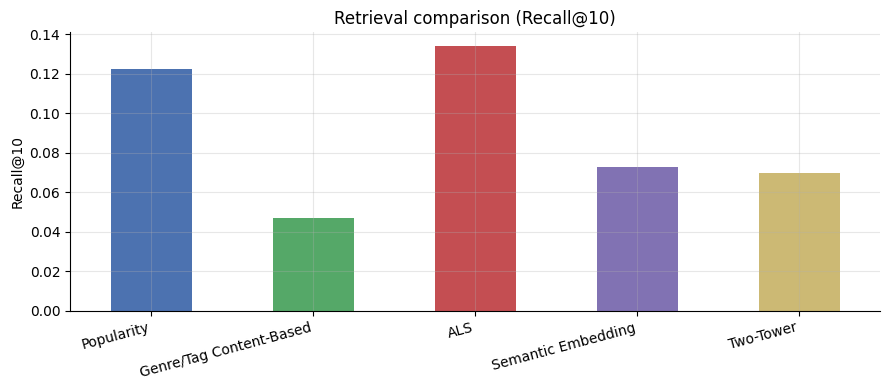

In [ ]:
K = 10
results = {}
results["Popularity"] = evaluate(PopularityRecommender().fit(train), train, test, k=K)
results["Genre/Tag Content-Based"] = evaluate(
    ContentBasedRecommender(games, genre_weight=2).fit(train), train, test, k=K)
results["ALS"] = evaluate(
    ALSRecommender(factors=128, iterations=25, regularization=0.05).fit(train), train, test, k=K)
results["Semantic Embedding"] = evaluate(
    SemanticEmbeddingRecommender(game_emb, game_ids).fit(train), train, test, k=K)
results["Two-Tower"] = evaluate(two_tower, train, test, k=K)

benchmark = pd.DataFrame(results).T[[f"Recall@{K}", f"MAP@{K}", f"NDCG@{K}"]].round(4)
print(benchmark.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
benchmark[f"Recall@{K}"].plot.bar(
    ax=ax, color=["#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974"])
ax.set_ylabel(f"Recall@{K}")
ax.set_title(f"Retrieval comparison (Recall@{K})")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## Embedding Validation

We inspect the **learned** item space the same way we inspected the semantic space in Notebook 04: a global PCA view first, then local nearest neighbours — comparing neighbours in the learned space against the semantic space.

Compared to semantic retrieval, neighbouring games are now influenced not only by textual similarity but also by collaborative interaction patterns learned during training.

## Проверка эмбеддингов

Изучаем **обученное** пространство айтемов так же, как семантическое в Ноутбуке 04: сначала общий вид через PCA, затем локальные ближайшие соседи — сравнивая соседей в обученном пространстве с семантическим.

В отличие от семантического retrieval, соседние игры теперь определяются не только текстовым сходством, но и коллаборативными паттернами взаимодействий, выученными во время обучения.

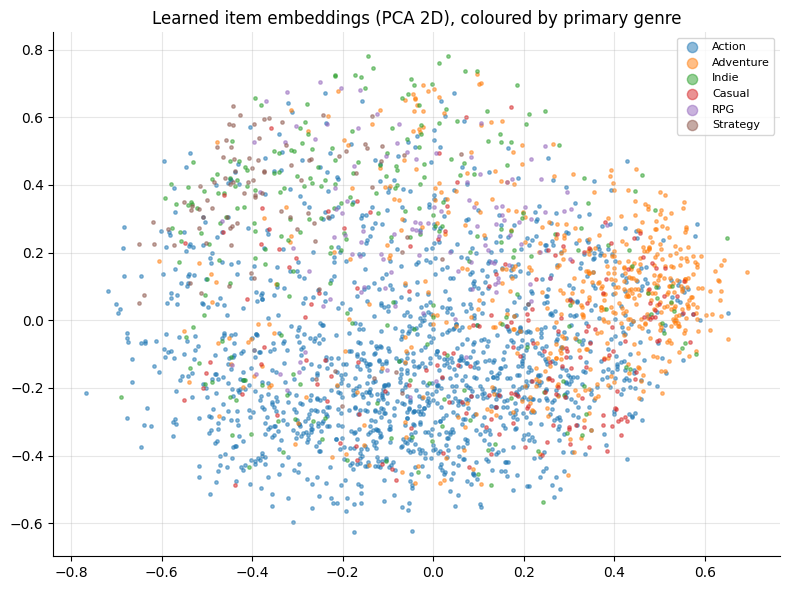

In [ ]:
# Global view: PCA of the learned item embeddings, coloured by primary genre
# Общий вид: PCA обученных эмбеддингов айтемов, окраска по основному жанру
learned = two_tower.item_emb_out_
prim = (games.set_index("game_id")["Genres"].fillna("")
        .map(lambda s: s.split(",")[0].strip() if s else ""))
prim_arr = prim.reindex(game_ids).fillna("").to_numpy()

coords = PCA(n_components=2, random_state=42).fit_transform(learned)
top6 = pd.Series(prim_arr)[pd.Series(prim_arr) != ""].value_counts().head(6).index
plt.figure(figsize=(8, 6))
for g in top6:
    sel = prim_arr == g
    plt.scatter(coords[sel, 0], coords[sel, 1], s=6, alpha=0.5, label=g)
plt.legend(markerscale=3, fontsize=8)
plt.title("Learned item embeddings (PCA 2D), coloured by primary genre")
plt.tight_layout()
plt.show()

In [ ]:
# Local view: nearest neighbours in the learned space vs the semantic space
# Локальный вид: ближайшие соседи в обученном пространстве против семантического
row_by_id = {g: i for i, g in enumerate(game_ids)}
learned_n = learned / (np.linalg.norm(learned, axis=1, keepdims=True) + 1e-12)

def neighbours(matrix, gid, k=6):
    sims = matrix @ matrix[row_by_id[gid]]
    idx = np.argsort(-sims)[1:k + 1]
    return [name_by_id.get(game_ids[j], game_ids[j]) for j in idx]

for nm in ["Counter-Strike", "Stardew Valley"]:
    m = games[games["Name"] == nm]
    if len(m) and m["game_id"].iloc[0] in row_by_id:
        gid = m["game_id"].iloc[0]
        print(f"\n{nm}")
        print("  semantic:", neighbours(game_emb, gid))
        print("  learned: ", neighbours(learned_n, gid))


Counter-Strike
  semantic: ['Counter-Strike: Condition Zero', 'Counter-Strike: Source', 'Counter-Strike 2', 'Grand Theft Auto V Legacy', 'Z1 Battle Royale', "Tom Clancy's Rainbow Six® Siege X"]
  learned:  ['Counter-Strike: Condition Zero', 'Counter-Strike: Source', 'Day of Defeat', 'Day of Defeat: Source', 'Quake Live', 'BATTALION: Legacy']

Stardew Valley
  semantic: ['Farm Together', 'Forager', 'Crashlands', 'ASTRONEER', 'Farming Simulator 19', 'Kingdom Two Crowns']
  learned:  ['Forager', 'Crashlands', 'Aground', 'Starbound', 'Terraria', 'Oxygen Not Included']


## Retrieval Evolution

| Stage | Best Model | What it captures |
|---|---|---|
| Classical Retrieval | ALS | Collaborative interaction patterns |
| Semantic Retrieval | Semantic Embedding | Textual game semantics |
| Neural Retrieval | Two-Tower | Jointly learned user and item representations |

The project did not just compare models — it changed how items and users are represented: fixed sparse vectors → fixed dense embeddings → jointly learned embeddings.

## Эволюция retrieval

| Этап | Лучшая модель | Что улавливает |
|---|---|---|
| Classical Retrieval | ALS | Коллаборативные паттерны взаимодействий |
| Semantic Retrieval | Semantic Embedding | Текстовую семантику игр |
| Neural Retrieval | Two-Tower | Совместно обучаемые представления юзера и игры |

Проект не просто сравнивал модели — он менял способ представления игр и пользователей: фиксированные разреженные векторы → фиксированные плотные эмбеддинги → совместно обучаемые эмбеддинги.

## Discussion

The model consistently improves over metadata-based retrieval, confirming that jointly learned representations capture richer user-item relationships than manually engineered features. The learned space also reflects collaborative structure: nearest neighbours are now shaped by how games are played together, not only by how they are described.

Nevertheless, ALS remains the strongest retrieval model on this benchmark. A likely explanation is the combination of sparse user histories, a relatively small item catalog and the absence of user identity embeddings in the current architecture.

Rather than maximizing retrieval performance alone, the goal of this stage is to establish a neural retrieval component that can be integrated into a multi-stage recommendation pipeline. The final ranking stage will exploit richer interaction features to improve recommendation quality.

## Обсуждение

Модель стабильно превосходит retrieval на метаданных, подтверждая, что совместно обучаемые представления улавливают более богатые связи пользователь–игра, чем сконструированные вручную признаки. Обученное пространство также отражает коллаборативную структуру: ближайшие соседи теперь определяются тем, как в игры играют вместе, а не только тем, как они описаны.

Тем не менее ALS остаётся сильнейшей retrieval-моделью на этом бенчмарке. Вероятное объяснение — сочетание разреженных историй пользователей, относительно маленького каталога игр и отсутствия ID-эмбеддингов пользователей в текущей архитектуре.

Цель этого этапа — не максимизировать сам retrieval, а создать нейронный retrieval-компонент, который встраивается в многостадийный рекомендательный пайплайн. Финальный этап ранжирования использует более богатые признаки взаимодействий, чтобы повысить качество рекомендаций.

## Next Step

Retrieval identifies a small set of relevant candidate items. The final ranking stage focuses on ordering these candidates using richer pairwise features (LightGBM LambdaMART).

## Следующий этап

Retrieval находит небольшой набор релевантных кандидатов. Финальный этап ранжирования сосредоточен на их упорядочивании с помощью более богатых попарных признаков (LightGBM LambdaMART).